In [1]:
import fastf1 as ff1
import pandas as pd
import numpy as np

# Abilitiamo la cache che hai già popolato
ff1.Cache.enable_cache('./cache')
# ff1.set_log_level('ERROR')
ff1.Cache.offline_mode(True)

In [ ]:
s1 = ff1.get_session(2024, 'monza', 'R')
s1.load(telemetry=False, weather=True)

In [9]:
circuits = pd.read_csv('./f1_data/f1_unique_circuits_complete.csv')

In [10]:
circuits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          25 non-null     object 
 1   Location         25 non-null     object 
 2   EventName        25 non-null     object 
 3   EventDate        25 non-null     object 
 4   TrackLenght      25 non-null     float64
 5   NumTurns         25 non-null     int64  
 6   RaceDistance     25 non-null     float64
 7   NumLaps          25 non-null     int64  
 8   Traction         25 non-null     int64  
 9   AsphaltGrip      25 non-null     int64  
 10  AsphaltAbrasion  25 non-null     int64  
 11  TrackEvolution   25 non-null     int64  
 12  TyreStress       25 non-null     int64  
 13  Braking          25 non-null     int64  
 14  LateralLoad      25 non-null     int64  
 15  Downforce        25 non-null     int64  
 16  Soft             25 non-null     object 
 17  Medium           2

Ricapitolando, il nostro nuovo df_encoded dovrà avere queste nuove colonne calcolate:

    TyreLife_Squared (per simulare il crollo).

    Tyre_Phase (per categorizzare l'usura).

    Track_Stress (da un dizionario fisso che creeremo noi).

    Season_Progress (per l'evoluzione tecnica dell'anno).

In [11]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD AND PREPARE CIRCUIT DATA
# ==========================================
print("📊 Loading Circuit Data...")
circuits_df = pd.read_csv('./f1_data/f1_unique_circuits_complete.csv')

# Select the physical characteristics provided by Pirelli
pirelli_features = [
    'Traction', 'AsphaltGrip', 'AsphaltAbrasion', 
    'TyreStress', 'Braking', 'LateralLoad', 'Downforce'
]

# Extract the features for clustering
X_circuits = circuits_df[pirelli_features]

# Standardize the data (Crucial for K-Means to work properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circuits)

# ==========================================
# 2. APPLY K-MEANS CLUSTERING
# ==========================================
print("🧠 Running K-Means Clustering...")
num_clusters = 4 # Let's try 4 archetypes (e.g., High-Deg, Stop&Go, Low-Deg, Balanced)

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
circuits_df['Track_Archetype'] = kmeans.fit_predict(X_scaled)

# ==========================================
# 3. ANALYZE THE CLUSTERS
# ==========================================
print("\n" + "="*50)
print("🏁 TRACK ARCHETYPES DISCOVERED")
print("="*50)

# Let's see which tracks ended up in which cluster
for cluster_id in range(num_clusters):
    tracks_in_cluster = circuits_df[circuits_df['Track_Archetype'] == cluster_id]['Location'].tolist()
    
    # Calculate the average stats for this cluster to name it
    avg_stats = circuits_df[circuits_df['Track_Archetype'] == cluster_id][pirelli_features].mean()
    
    print(f"\n🟢 CLUSTER {cluster_id}: {', '.join(tracks_in_cluster)}")
    print(f"   Avg Stress: {avg_stats['TyreStress']:.1f}/5 | Avg Lateral: {avg_stats['LateralLoad']:.1f}/5 | Avg Braking: {avg_stats['Braking']:.1f}/5")

# Save this enhanced circuits dataframe for later merging
circuits_df.to_csv('./f1_data/f1_circuits_clustered.csv', index=False)
print("\n💾 Saved clustered circuits to './f1_data/f1_circuits_clustered.csv'")

📊 Loading Circuit Data...
🧠 Running K-Means Clustering...

🏁 TRACK ARCHETYPES DISCOVERED

🟢 CLUSTER 0: Montréal, Monza, Baku, Las Vegas
   Avg Stress: 3.2/5 | Avg Lateral: 1.5/5 | Avg Braking: 4.0/5

🟢 CLUSTER 1: Sakhir, Monaco, Budapest, Marina Bay, Mexico City, Yas Island
   Avg Stress: 2.3/5 | Avg Lateral: 2.3/5 | Avg Braking: 3.5/5

🟢 CLUSTER 2: Melbourne, Jeddah, Miami, Imola, Spielberg, São Paulo
   Avg Stress: 3.0/5 | Avg Lateral: 3.2/5 | Avg Braking: 2.8/5

🟢 CLUSTER 3: Shanghai, Suzuka, Barcelona, Silverstone, Spa-Francorchamps, Zandvoort, Austin, Lusail, Le Castellet
   Avg Stress: 4.7/5 | Avg Lateral: 4.6/5 | Avg Braking: 2.9/5

💾 Saved clustered circuits to './f1_data/f1_circuits_clustered.csv'


c:\Users\lucam\anaconda3\envs\myenv_mlf1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [45]:
import os

data_dir = './f1_data'
data_file = os.path.join(data_dir, 'f1_strategy_dataset_22_25.csv')
circuit_file = os.path.join(data_dir, 'f1_circuits_clustered.csv')

df_data = pd.read_csv(data_file)
df_circuits = pd.read_csv(circuit_file)

In [46]:
features_to_keep = [
    'Year', 'GP', 'Driver', 'Team', 'Compound', 'TyreLife', 'FreshTyre', 
    'Stint', 'LapNumber', 'FuelLoad', 'TrackTemp', 'TrackEvolution', 
    'InTraffic', 'LapTimeSeconds', 'TrackStatus'
]

def clean_f1_data_ml(df):
    df_clean = df[features_to_keep].copy()

    # Keep only green flags laps
    df_clean = df_clean[df_clean['TrackStatus'] == 1]

    # Only dry compound
    df_clean = df_clean[df_clean['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
    
    # Driver-specific Outlier Removal
    def remove_driver_outliers(group):
        # Using a 7% threshold over the median lap time for that specific driver/stint
        # This removes mistakes, pit entries not caught by FastF1, or yellow flag sectors
        driver_median = group['LapTimeSeconds'].median()
        return group[group['LapTimeSeconds'] < (driver_median * 1.07)]

    # Apply the filtering logic
    df_clean = df_clean.groupby(
        ['Year', 'GP', 'Driver', 'Compound'], 
        group_keys=False
    ).apply(remove_driver_outliers, include_groups=True).reset_index(drop=True)

    # Fixing names
    # Team names mapping to unify technical cycles
    df_clean['Team'] = df_clean['Team'].replace(['AlphaTauri', 'Racing Bulls'], 'RB')
    df_clean['Team'] = df_clean['Team'].replace(['Alfa Romeo'], 'Kick Sauber')
   
    df_clean['FuelLoad'] = df_clean["FuelLoad"].apply(lambda x: x + 1)

    return df_clean

In [47]:
# ==========================================
# 2. THE V2 FEATURE ENGINEERING PIPELINE
# ==========================================
def build_v2_features(main_df, circuits_df):
    """
    Merges circuit physical stats, compound mappings, and creates new V2 features
    like TyreLife_Squared and Season_Progress.
    """
    print("⚙️ Building V2 Features...")
    
    # 1. Merge all circuit data (Compounds, Stats, Archetypes, and Dates)
    cols_to_merge = [
        'EventName', 'EventDate', 'Soft', 'Medium', 'Hard', 
        'Track_Archetype', 'TyreStress', 'AsphaltAbrasion', 
        'LateralLoad', 'Braking'
    ]
    
    df_merged = pd.merge(
        main_df, 
        circuits_df[cols_to_merge], 
        left_on='GP', 
        right_on='EventName', 
        how='left'
    )

    # 2. Fill Missing Values (e.g., France 2022 if absent)
    df_merged['Soft'] = df_merged['Soft'].fillna('C4')
    df_merged['Medium'] = df_merged['Medium'].fillna('C3')
    df_merged['Hard'] = df_merged['Hard'].fillna('C2')
    
    # Fill missing circuit stats with the overall median
    for col in ['Track_Archetype', 'TyreStress', 'AsphaltAbrasion', 'LateralLoad', 'Braking']:
        df_merged[col] = df_merged[col].fillna(df_merged[col].median())

    # 3. Create SpecificCompound (C1 to C5)
    def get_specific_c(row):
        compound = str(row['Compound']).upper()
        if 'SOFT' in compound: return row['Soft']
        elif 'MEDIUM' in compound: return row['Medium']
        elif 'HARD' in compound: return row['Hard']
        return np.nan
        
    df_merged['SpecificCompound'] = df_merged.apply(get_specific_c, axis=1)

    # ----------------------------------------------------
    # NEW V2 FEATURES
    # ----------------------------------------------------
    # A. TyreLife Squared (To force XGBoost to learn the "Cliff")
    df_merged['TyreLife_Squared'] = df_merged['TyreLife'] ** 2
    
    # B. Season Progress (0.0 to 1.0 to represent car development over the year)
    # df_merged['EventDate'] = pd.to_datetime(df_merged['EventDate'])
    
    # def calculate_season_progress(group):
    #     min_date = group['EventDate'].min()
    #     max_date = group['EventDate'].max()
    #     # Prevent division by zero if a year has only 1 race in data
    #     if min_date == max_date:
    #         group['Season_Progress'] = 0.5 
    #     else:
    #         # Calculate fraction of the season completed
    #         group['Season_Progress'] = (group['EventDate'] - min_date) / (max_date - min_date)
    #     return group
        
    # df_merged = df_merged.groupby('Year', group_keys=False).apply(calculate_season_progress)
    
    # C. Calculate the Target Variable (LapDeltaSeconds)
    # We still use 'Year' here to ensure the best lap is relative to that specific season!
    best_laps = df_merged.groupby(['Year', 'GP'])['LapTimeSeconds'].transform('min')
    df_merged['LapDeltaSeconds'] = df_merged['LapTimeSeconds'] - best_laps

    # 4. Clean up temporary columns
    df_merged = df_merged.drop(columns=['EventName', 'Soft', 'Medium', 'Hard', 'index', 'level_0'], errors='ignore')
    
    print("✅ V2 Feature Engineering Complete!")
    return df_merged

In [48]:
# ==========================================
# 3. EXECUTION
# ==========================================
# Assuming df_data and df_circuits are loaded
# df_data = pd.read_csv(r'.\f1_data\f1_strategy_dataset_22_25.csv')
# df_circuits = pd.read_csv(r'.\f1_data\f1_circuits_clustered.csv')

df_ready_for_ml = clean_f1_data_ml(df_data)
print(f"Data cleaning complete. Remaining samples: {len(df_ready_for_ml)}")

df_final_v2 = build_v2_features(df_ready_for_ml, df_circuits)

C:\Users\lucam\AppData\Local\Temp\ipykernel_18968\3098247216.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(remove_driver_outliers, include_groups=True).reset_index(drop=True)


Data cleaning complete. Remaining samples: 62291
⚙️ Building V2 Features...
✅ V2 Feature Engineering Complete!


In [49]:
def check_dataset_integrity(df):
    """
    Checks for missing values and provides a summary of the dataset health.
    """
    print("--- Dataset Integrity Check ---")
    
    # 1. Count nulls per column
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    
    # 2. Filter only columns with nulls
    missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total Nulls', 'Percentage'])
    missing_data = missing_data[missing_data['Total Nulls'] > 0]
    
    if missing_data.empty:
        print("✅ No missing values found! The dataset is clean.")
    else:
        print("⚠️ Missing values detected:")
        print(missing_data)
        
    # 3. Check for 'SpecificCompound' validity
    # We want to make sure we don't have 'nan' strings or empty values here
    unique_compounds = df['SpecificCompound'].unique()
    print(f"\nDetected Compounds: {unique_compounds}")
    
    return missing_data

# Run the check
missing_report = check_dataset_integrity(df_final_v2)

--- Dataset Integrity Check ---
⚠️ Missing values detected:
                  Total Nulls  Percentage
TyreLife                   58    0.093111
TyreLife_Squared           58    0.093111

Detected Compounds: ['C3' 'C4' 'C5' 'C6' 'C2' 'C1']


In [50]:
# Drop rows where TyreLife is NaN
df_final_v2 = df_final_v2.dropna(subset=['TyreLife'])

# Reset index to ensure it's continuous after drops
df_final_v2 = df_final_v2.reset_index(drop=True)

print(f"Final clean dataset size: {len(df_final_v2)} rows")

Final clean dataset size: 62233 rows


In [51]:
df_final_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62233 entries, 0 to 62232
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              62233 non-null  int64  
 1   GP                62233 non-null  object 
 2   Driver            62233 non-null  object 
 3   Team              62233 non-null  object 
 4   Compound          62233 non-null  object 
 5   TyreLife          62233 non-null  float64
 6   FreshTyre         62233 non-null  bool   
 7   Stint             62233 non-null  float64
 8   LapNumber         62233 non-null  float64
 9   FuelLoad          62233 non-null  float64
 10  TrackTemp         62233 non-null  float64
 11  TrackEvolution    62233 non-null  float64
 12  InTraffic         62233 non-null  int64  
 13  LapTimeSeconds    62233 non-null  float64
 14  TrackStatus       62233 non-null  int64  
 15  EventDate         62233 non-null  object 
 16  Track_Archetype   62233 non-null  int64 

In [52]:
from sklearn.preprocessing import LabelEncoder

def apply_final_encoding(df):
    """
    Transforms categorical strings into numerical values for ML.
    """
    # 1. Ordinal Mapping for Compounds (Physical hierarchy)
    compound_map = {
        'C1': 1, 'C2': 2, 'C3': 3, 'C4': 4, 'C5': 5, 'C6': 6
    }
    df['SpecificCompound_Encoded'] = df['SpecificCompound'].map(compound_map)

    # 2. Label Encoding for Team
    team_le = LabelEncoder()
    df['Team_Encoded'] = team_le.fit_transform(df['Team'])
    
    # 3. Label Encoding for Driver
    driver_le = LabelEncoder()
    df['Driver_Encoded'] = driver_le.fit_transform(df['Driver'])
    
    # 4. Label Encoding for GP (Crucial for track characteristics!)
    gp_le = LabelEncoder()
    df['GP_Encoded'] = gp_le.fit_transform(df['GP'])

    # 5. Binary Encoding for FreshTyre (Boolean to 0/1)
    df['FreshTyre'] = df['FreshTyre'].astype(int)

    # Store encoders if we need to inverse_transform later
    return df, team_le, driver_le, gp_le

# Execution
df_encoded_v2, team_encoder, driver_encoder, gp_encoder = apply_final_encoding(df_final_v2)

# Display the mapping for verification
print("Team Mapping:", dict(zip(team_encoder.classes_, team_encoder.transform(team_encoder.classes_))))
print("Driver Mapping:", dict(zip(driver_encoder.classes_, driver_encoder.transform(driver_encoder.classes_)))) 
print("GP Mapping:", dict(zip(gp_encoder.classes_, gp_encoder.transform(gp_encoder.classes_))))
print(f"SpecificCompound unique values: {df_encoded_v2['SpecificCompound_Encoded'].unique()}")

Team Mapping: {'Alpine': np.int64(0), 'Aston Martin': np.int64(1), 'Ferrari': np.int64(2), 'Haas F1 Team': np.int64(3), 'Kick Sauber': np.int64(4), 'McLaren': np.int64(5), 'Mercedes': np.int64(6), 'RB': np.int64(7), 'Red Bull Racing': np.int64(8), 'Williams': np.int64(9)}
Driver Mapping: {'ALB': np.int64(0), 'ALO': np.int64(1), 'ANT': np.int64(2), 'BEA': np.int64(3), 'BOR': np.int64(4), 'BOT': np.int64(5), 'COL': np.int64(6), 'DEV': np.int64(7), 'DOO': np.int64(8), 'GAS': np.int64(9), 'HAD': np.int64(10), 'HAM': np.int64(11), 'HUL': np.int64(12), 'LAT': np.int64(13), 'LAW': np.int64(14), 'LEC': np.int64(15), 'MAG': np.int64(16), 'MSC': np.int64(17), 'NOR': np.int64(18), 'OCO': np.int64(19), 'PER': np.int64(20), 'PIA': np.int64(21), 'RIC': np.int64(22), 'RUS': np.int64(23), 'SAI': np.int64(24), 'SAR': np.int64(25), 'STR': np.int64(26), 'TSU': np.int64(27), 'VER': np.int64(28), 'VET': np.int64(29), 'ZHO': np.int64(30)}
GP Mapping: {'Abu Dhabi Grand Prix': np.int64(0), 'Australian Grand P

In [57]:
df_encoded_v2

,Year,GP,Driver,Team,Compound,TyreLife,FreshTyre,Stint,LapNumber,FuelLoad,...,AsphaltAbrasion,LateralLoad,Braking,SpecificCompound,TyreLife_Squared,LapDeltaSeconds,SpecificCompound_Encoded,Team_Encoded,Driver_Encoded,GP_Encoded
0,2022,Abu Dhabi Grand Prix,ALB,Williams,HARD,2.0,1,2.0,14.0,76.862069,...,3,3,4,C3,4.0,2.591,3,9,0,0
1,2022,Abu Dhabi Grand Prix,ALB,Williams,HARD,3.0,1,2.0,15.0,75.137931,...,3,3,4,C3,9.0,3.039,3,9,0,0
2,2022,Abu Dhabi Grand Prix,ALB,Williams,HARD,4.0,1,2.0,16.0,73.413793,...,3,3,4,C3,16.0,3.194,3,9,0,0
3,2022,Abu Dhabi Grand Prix,ALB,Williams,HARD,5.0,1,2.0,17.0,71.689655,...,3,3,4,C3,25.0,3.105,3,9,0,0
4,2022,Abu Dhabi Grand Prix,ALB,Williams,HARD,6.0,1,2.0,18.0,69.965517,...,3,3,4,C3,36.0,3.445,3,9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62228,2025,Spanish Grand Prix,VER,Red Bull Racing,SOFT,6.0,0,4.0,50.0,25.242424,...,4,5,3,C3,36.0,2.254,3,8,28,20
62229,2025,Spanish Grand Prix,VER,Red Bull Racing,SOFT,7.0,0,4.0,51.0,23.727273,...,4,5,3,C3,49.0,2.991,3,8,28,20
62230,2025,Spanish Grand Prix,VER,Red Bull Racing,SOFT,8.0,0,4.0,52.0,22.212121,...,4,5,3,C3,64.0,2.939,3,8,28,20
62231,2025,Spanish Grand Prix,VER,Red Bull Racing,SOFT,9.0,0,4.0,53.0,20.696970,...,4,5,3,C3,81.0,3.198,3,8,28,20


In [54]:
data_dir = './f1_data'
os.makedirs(data_dir, exist_ok=True)

output_file = os.path.join(data_dir, 'f1_dataset_encoded_v2.csv')
df_encoded_v2.to_csv(output_file, index=False)
print(f"\n✅ Dataset saved to {output_file} | Total rows: {len(df_encoded_v2)}")


✅ Dataset saved to ./f1_data\f1_dataset_encoded_v2.csv | Total rows: 62233


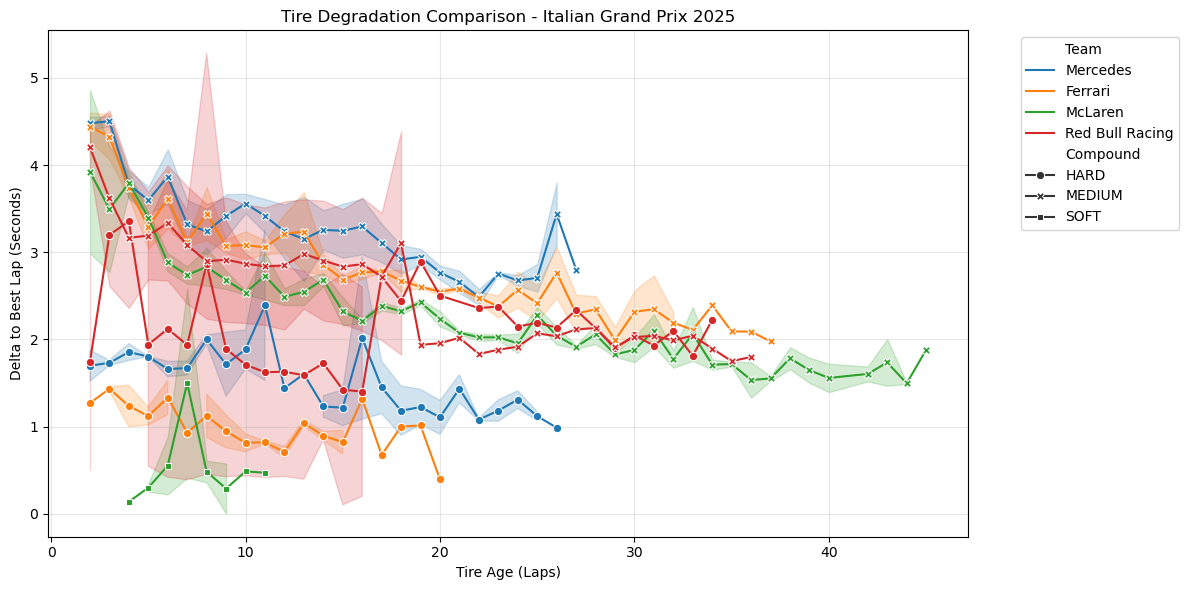

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_degradation_trend(df, gp_name, year):
    # Filter for a specific race
    # Note: using 'str.contains' for GP to handle 'Italian Grand Prix' vs 'Monza'
    race_data = df[(df['GP'].str.contains(gp_name)) & (df['Year'] == year)].copy()
    
    if race_data.empty:
        print(f"No data found for {gp_name} {year}")
        return

    plt.figure(figsize=(12, 6))
    
    # Filter for main teams
    top_teams = ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren']
    filtered_teams = race_data[race_data['Team'].isin(top_teams)]
    
    sns.lineplot(
        data=filtered_teams, 
        x='TyreLife', 
        y='LapDeltaSeconds', 
        hue='Team', 
        style='Compound',
        markers=True, 
        dashes=False
    )
    
    plt.title(f"Tire Degradation Comparison - {gp_name} {year}")
    plt.xlabel("Tire Age (Laps)")
    plt.ylabel("Delta to Best Lap (Seconds)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the plot
plot_degradation_trend(df_encoded_v2, 'Italian Grand Prix', 2025)

________

In [70]:
# 1. Define the correct features and target
features_v2 = [
    'Year', 'TyreLife', 'TyreLife_Squared', 'FuelLoad', 'TrackTemp', 'TrackEvolution', 'InTraffic',
    'FreshTyre', 'Track_Archetype', 'TyreStress', 'AsphaltAbrasion', 'LateralLoad', 'Braking',
    'SpecificCompound_Encoded', 'Team_Encoded', 'Driver_Encoded', 'GP_Encoded'
]

target = 'LapDeltaSeconds'

# 2. Extract 2025 data and find the midpoint
data_2025 = df_encoded_v2[df_encoded_v2['Year'] == 2025].copy()
gps_2025_chronological = data_2025['GP'].unique() # Preserves the order they were loaded

# Let's split 2025 in half (e.g., first 12 races for training, rest for testing)
midpoint = len(gps_2025_chronological) // 2
train_gps_2025 = gps_2025_chronological[:midpoint]
test_gps_2025 = gps_2025_chronological[midpoint:]

# 3. Create the Training Set (2022-2024 + First Half of 2025)
train_data_historical = df_encoded_v2[df_encoded_v2['Year'] < 2025]
train_data_2025 = data_2025[data_2025['GP'].isin(train_gps_2025)]

train_data = pd.concat([train_data_historical, train_data_2025])

# 4. Create the Test Set (Second Half of 2025)
test_data = data_2025[data_2025['GP'].isin(test_gps_2025)]

# 5. Finalize X and y
X_train = train_data[features_v2]
y_train = train_data[target]

X_test = test_data[features_v2]
y_test = test_data[target]

print("\n" + "="*50)
print("🏁 DATA SPLIT COMPLETE")
print("="*50)
print(f"Training samples (2022 -> Mid 2025): {len(X_train)}")
print(f"Test samples (Late 2025 Blind Test): {len(X_test)}")
print(f"Test GPs: {list(test_gps_2025)}")
print("="*50)


🏁 DATA SPLIT COMPLETE
Training samples (2022 -> Mid 2025): 53089
Test samples (Late 2025 Blind Test): 9144
Test GPs: ['Hungarian Grand Prix', 'Italian Grand Prix', 'Japanese Grand Prix', 'Las Vegas Grand Prix', 'Mexico City Grand Prix', 'Monaco Grand Prix', 'Saudi Arabian Grand Prix', 'Singapore Grand Prix', 'Spanish Grand Prix']


🚀 V2 model (Baseline with V1 params)...
🧠 Training...
🎯 Validation (Blind Test 2025)...

🏆 BASELINE RESULTS V2
------------------------------
📊 Model Performance (Test Set):
Mean Absolute Error (MAE): 0.985 seconds
Root Mean Squared Error (RMSE): 1.260 seconds
------------------------------


<Figure size 1000x600 with 0 Axes>

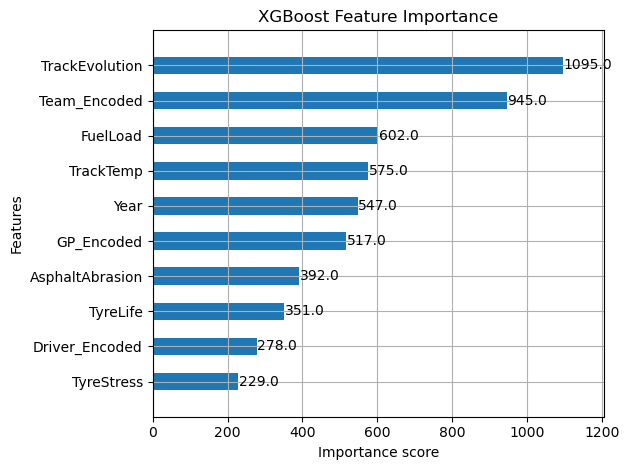

In [72]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

print("🚀 V2 model (Baseline with V1 params)...")

v1_best_params = {
    'n_estimators': 900,
    'learning_rate': 0.008,
    'max_depth': 3,
    'min_child_weight': 5,
    'gamma': 0.5,
    'subsample': 0.6,
    'colsample_bytree': 0.6,
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:squarederror'
}

# 1. Creazione e Addestramento
xgb_v2_baseline = xgb.XGBRegressor(**v1_best_params)

print("🧠 Training...")
xgb_v2_baseline.fit(X_train, y_train)

# 2. Previsione sul Blind Test (Seconda metà 2025)
print("🎯 Validation (Blind Test 2025)...")
y_pred_v2 = xgb_v2_baseline.predict(X_test)

# 3. Calcolo dell'Errore
mae_v2 = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))

print("\n" + "="*50)
print(f"🏆 BASELINE RESULTS V2")
print("-" * 30)
print(f"📊 Model Performance (Test Set):")
print(f"Mean Absolute Error (MAE): {mae_v2:.3f} seconds")
print(f"Root Mean Squared Error (RMSE): {rmse_v2:.3f} seconds")
print("-" * 30)


plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_v2_baseline, importance_type='weight', max_num_features=10, height=0.5)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

🚀 Initiating V2 Hyperparameter Optimization (Randomized Search)...
🧠 Training and Tuning in progress... (This might take a few minutes)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🏆 V2 OPTIMIZATION COMPLETE (Time: 0.5 min)
🌟 Best Hyperparameters Found:
   - subsample: 0.8
   - n_estimators: 600
   - min_child_weight: 5
   - max_depth: 7
   - learning_rate: 0.02
   - gamma: 1.0
   - colsample_bytree: 0.6

🎯 Validation (Blind Test 2025)...
------------------------------
📊 Tuned Model Performance (Test Set):
Mean Absolute Error (MAE): 1.034 seconds
Root Mean Squared Error (RMSE): 1.363 seconds
------------------------------


<Figure size 1000x600 with 0 Axes>

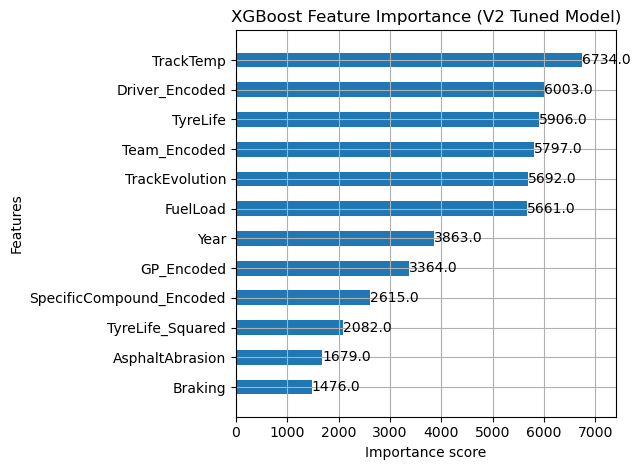

In [73]:
import time
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print("🚀 Initiating V2 Hyperparameter Optimization (Randomized Search)...")

# 1. Define the Expanded Search Space for V2
# We are increasing max_depth to allow the model to understand complex interactions
# between the new physical track features and tire life.
param_dist = {
    'n_estimators': [600, 800, 1000, 1200],
    'learning_rate': [0.01, 0.02, 0.05],
    'max_depth': [4, 5, 6, 7],
    'min_child_weight': [3, 5, 7],
    'gamma': [0.1, 0.5, 1.0],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

# 2. Instantiate the Base Model
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

# 3. Setup the Randomized Search
# n_iter=20 means it will test 20 different random combinations from the grid above.
# cv=3 means it will use 3-fold cross-validation to ensure the model generalizes well.
random_search_v2 = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,                               
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Execute the Search
print("🧠 Training and Tuning in progress... (This might take a few minutes)")
start_time = time.time()

random_search_v2.fit(X_train, y_train)

end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60

# 5. Extract Best Model and Parameters
best_v2_model = random_search_v2.best_estimator_
best_v2_params = random_search_v2.best_params_

print("\n" + "="*50)
print(f"🏆 V2 OPTIMIZATION COMPLETE (Time: {elapsed_minutes:.1f} min)")
print("="*50)
print("🌟 Best Hyperparameters Found:")
for param, value in best_v2_params.items():
    print(f"   - {param}: {value}")

# 6. Validate on the Blind Test (Late 2025 Data)
print("\n🎯 Validation (Blind Test 2025)...")
y_pred_best_v2 = best_v2_model.predict(X_test)

mae_best_v2 = mean_absolute_error(y_test, y_pred_best_v2)
rmse_best_v2 = np.sqrt(mean_squared_error(y_test, y_pred_best_v2))

print("-" * 30)
print(f"📊 Tuned Model Performance (Test Set):")
print(f"Mean Absolute Error (MAE): {mae_best_v2:.3f} seconds")
print(f"Root Mean Squared Error (RMSE): {rmse_best_v2:.3f} seconds")
print("-" * 30)

# 7. Plot the New Feature Importance
# Let's see if TyreLife_Squared or other features jumped up with more depth!
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_v2_model, importance_type='weight', max_num_features=12, height=0.5)
plt.title("XGBoost Feature Importance (V2 Tuned Model)")
plt.tight_layout()
plt.show()

In [ ]:
import time
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("🚀 Initiating V2.1 Anti-Overfitting Optimization...")

# 1. The Regularized Search Space
# We pull back max_depth and increase min_child_weight and gamma to force the model
# to look at macro-trends rather than memorizing track temperatures.
param_dist_v3 = {
    'n_estimators': [700, 900, 1000],
    'learning_rate': [0.008, 0.01, 0.015], # Slowing down the learning to prevent jumping to conclusions
    'max_depth': [3, 4, 5],                # STRICT LIMIT: No more 6 or 7!
    'min_child_weight': [5, 10, 15],       # HIGH values demand more evidence before splitting a tree
    'gamma': [0.5, 1.0, 2.0],              # Pruning: cuts branches that don't improve the overall score
    'subsample': [0.5, 0.6, 0.7],          # Only show a fraction of data to each tree to force generalization
    'colsample_bytree': [0.5, 0.6, 0.7]
}

# 2. Instantiate the Base Model
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

# 3. Setup the Randomized Search
random_search_v3 = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_v3,
    n_iter=20,                               
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 4. Execute
print("🧠 Training with strict anti-overfitting rules...")
start_time = time.time()
random_search_v3.fit(X_train, y_train)
elapsed_minutes = (time.time() - start_time) / 60

# 5. Extract Best Model
best_v3_model = random_search_v3.best_estimator_

print("\n" + "="*50)
print(f"🏆 ANTI-OVERFITTING OPTIMIZATION COMPLETE ({elapsed_minutes:.1f} min)")
print("="*50)
for param, value in random_search_v3.best_params_.items():
    print(f"   - {param}: {value}")

# 6. Validate on the Blind Test
print("\n🎯 Validation (Blind Test 2025)...")
y_pred_best_v3 = best_v3_model.predict(X_test)

mae_best_v3 = mean_absolute_error(y_test, y_pred_best_v3)
rmse_best_v3 = np.sqrt(mean_squared_error(y_test, y_pred_best_v3))

print("-" * 30)
print(f"📊 Regularized Model Performance (Test Set):")
print(f"Mean Absolute Error (MAE): {mae_best_v3:.3f} seconds")
print(f"Root Mean Squared Error (RMSE): {rmse_best_v3:.3f} seconds")
print("-" * 30)

🚀 Initiating V2.1 Anti-Overfitting Optimization...
🧠 Training with strict anti-overfitting rules...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🏆 ANTI-OVERFITTING OPTIMIZATION COMPLETE (0.3 min)
   - subsample: 0.5
   - n_estimators: 900
   - min_child_weight: 15
   - max_depth: 3
   - learning_rate: 0.008
   - gamma: 0.5
   - colsample_bytree: 0.5

🎯 Validation (Blind Test 2025)...
------------------------------
📊 Regularized Model Performance (Test Set):
Mean Absolute Error (MAE): 0.935 seconds
Root Mean Squared Error (RMSE): 1.209 seconds
------------------------------


<Figure size 1000x600 with 0 Axes>

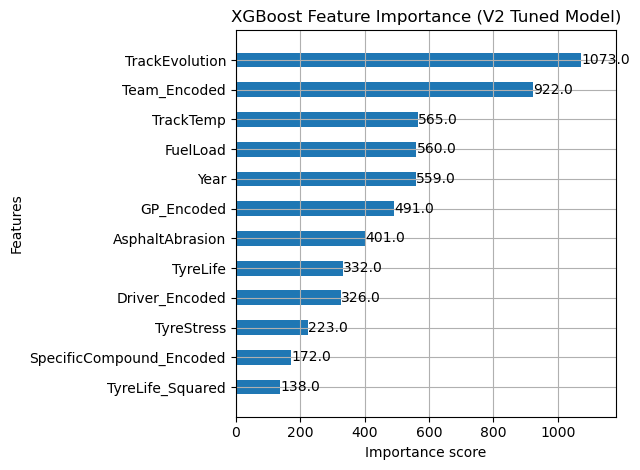

In [75]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_v3_model, importance_type='weight', max_num_features=12, height=0.5)
plt.title("XGBoost Feature Importance (V2 Tuned Model)")
plt.tight_layout()
plt.show()

In [76]:
import time
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("🚀 Initiating V2.2 Ultimate Micro-Tuning (Full Grid Search)...")

# 1. The Micro-Grid Space
# Centered exactly around the best results from the RandomizedSearchCV
param_grid_ultimate = {
    'n_estimators': [850, 900, 950],             # Tweak the number of trees slightly
    'learning_rate': [0.007, 0.008, 0.009],      # Micro-adjustments to learning speed
    'max_depth': [3],                            # Locked at 3 (we know >3 causes overfitting)
    'min_child_weight': [13, 15, 17],            # Fine-tuning the strictness
    'gamma': [0.4, 0.5, 0.6],                    # Pruning threshold
    'subsample': [0.45, 0.5, 0.55],              # Tweaking the data slice per tree
    'colsample_bytree': [0.45, 0.5, 0.55]        # Tweaking the feature slice per tree
}

# 2. Instantiate the Base Model
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

# 3. Setup the Full Grid Search
# Warning: 3x3x1x3x3x3x3 = 729 combinations * 3 folds = 2187 total fits!
grid_search_ultimate = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_ultimate,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1, # Set to 1 to avoid flooding the console, but still see progress
    n_jobs=-1
)

# 4. Execute the Brute-Force Search
print("🧠 Training EXHAUSTIVE Grid Search... (Grab a coffee, this will take time)")
start_time = time.time()
grid_search_ultimate.fit(X_train, y_train)
elapsed_minutes = (time.time() - start_time) / 60

# 5. Extract Ultimate Best Model
ultimate_v2_model = grid_search_ultimate.best_estimator_

print("\n" + "="*60)
print(f"🏆 ULTIMATE GRID SEARCH COMPLETE ({elapsed_minutes:.1f} min)")
print("="*60)
for param, value in grid_search_ultimate.best_params_.items():
    print(f"   - {param}: {value}")

# 6. Validate on the Blind Test
print("\n🎯 Final Validation (Blind Test 2025)...")
y_pred_ultimate = ultimate_v2_model.predict(X_test)

mae_ultimate = mean_absolute_error(y_test, y_pred_ultimate)
rmse_ultimate = np.sqrt(mean_squared_error(y_test, y_pred_ultimate))

print("-" * 40)
print(f"📊 Ultimate Model Performance (Test Set):")
print(f"Mean Absolute Error (MAE): {mae_ultimate:.4f} seconds")
print(f"Root Mean Squared Error (RMSE): {rmse_ultimate:.4f} seconds")
print("-" * 40)

# Optional: Compare with previous best
previous_best_mae = 0.935 
improvement = previous_best_mae - mae_ultimate
if improvement > 0:
    print(f"🎉 WE IMPROVED! Squeezed an extra {improvement:.4f} seconds of accuracy!")
else:
    print(f"🛡️ The Random Search was already optimal. The baseline remains unbeatable.")


🚀 Initiating V2.2 Ultimate Micro-Tuning (Full Grid Search)...
🧠 Training EXHAUSTIVE Grid Search... (Grab a coffee, this will take time)
Fitting 3 folds for each of 729 candidates, totalling 2187 fits

🏆 ULTIMATE GRID SEARCH COMPLETE (8.2 min)
   - colsample_bytree: 0.45
   - gamma: 0.4
   - learning_rate: 0.009
   - max_depth: 3
   - min_child_weight: 17
   - n_estimators: 950
   - subsample: 0.5

🎯 Final Validation (Blind Test 2025)...
----------------------------------------
📊 Ultimate Model Performance (Test Set):
Mean Absolute Error (MAE): 0.9247 seconds
Root Mean Squared Error (RMSE): 1.2023 seconds
----------------------------------------
🎉 WE IMPROVED! Squeezed an extra 0.0103 seconds of accuracy!


<Figure size 1000x600 with 0 Axes>

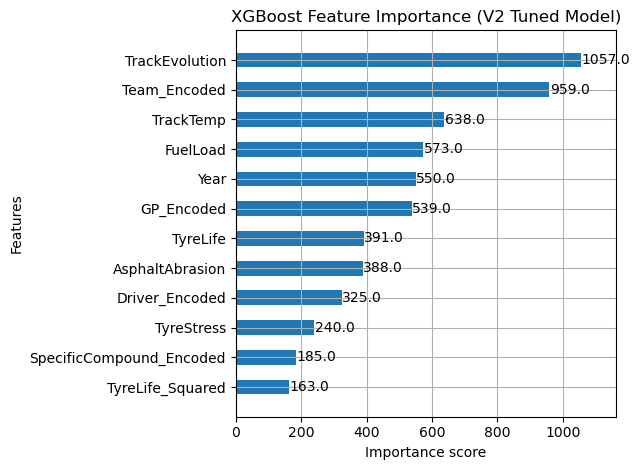

In [77]:

plt.figure(figsize=(10, 6))
xgb.plot_importance(ultimate_v2_model, importance_type='weight', max_num_features=12, height=0.5)
plt.title("XGBoost Feature Importance (V2 Tuned Model)")
plt.tight_layout()
plt.show()

In [78]:
import joblib

# ==========================================
# 💾 SAVE THE ULTIMATE MODEL AND ENCODERS
# ==========================================

print("💾 Saving the Ultimate V2 Model and your Encoders to disk...")

# 1. Save the XGBoost Model
model_filename = 'f1_ultimate_v2_model.pkl'
joblib.dump(ultimate_v2_model, model_filename)
print(f"✅ Model saved successfully as '{model_filename}'")

# 2. Bundle your specific encoders into a dictionary and save it
# This keeps your folder clean instead of creating 3 different files
encoders_bundle = {
    'team_encoder': team_encoder,
    'driver_encoder': driver_encoder,
    'gp_encoder': gp_encoder
}

encoders_filename = 'f1_encoders_bundle_v2.pkl'
joblib.dump(encoders_bundle, encoders_filename)
print(f"✅ Encoders saved successfully as '{encoders_filename}'")

print("\n🔒 Backup complete! Everything is perfectly safe.")

# ---------------------------------------------------------
# 💡 QUICK TIP: How to load them back tomorrow
# ---------------------------------------------------------
# ultimate_v2_model = joblib.load('f1_ultimate_v2_model.pkl')
# loaded_encoders = joblib.load('f1_encoders_bundle_v2.pkl')
#
# team_encoder = loaded_encoders['team_encoder']
# driver_encoder = loaded_encoders['driver_encoder']
# gp_encoder = loaded_encoders['gp_encoder']

💾 Saving the Ultimate V2 Model and your Encoders to disk...
✅ Model saved successfully as 'f1_ultimate_v2_model.pkl'
✅ Encoders saved successfully as 'f1_encoders_bundle_v2.pkl'

🔒 Backup complete! Everything is perfectly safe.


_________

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 11. THE V2 RACE SIMULATOR
# ==========================================

def simulate_strategy_v2(model, race_config, strategy_dict, track_evo_curve):
    """
    Updated simulator to handle the 17 features of the V2 Ultimate Model.
    """
    total_time = 0.0
    current_tyre_life = 0
    current_compound_encoded = strategy_dict[1] 
    
    # 100kg of fuel, burning ~1.4kg per lap (71 laps)
    current_fuel = 100.0 
    fuel_burn_rate = 100.0 / race_config['total_laps']
    
    for lap in range(1, race_config['total_laps'] + 1):
        # 1. Pit Stop Logic
        is_pit_lap = False
        if lap in strategy_dict and lap != 1:
            current_compound_encoded = strategy_dict[lap]
            current_tyre_life = 0
            total_time += race_config['pit_stop_loss']
            is_pit_lap = True
            
        current_tyre_life += 1
        fresh_tyre = 1 if current_tyre_life <= 3 else 0
        
        # 2. Track Evolution Logic
        evo_val = track_evo_curve.get(lap, list(track_evo_curve.values())[-1])
        
        # 3. BUILD THE V2 FEATURE ROW (Must match features_v2 exactly!)
        lap_features = pd.DataFrame([{
            'Year': race_config['Year'],
            'TyreLife': current_tyre_life,
            'TyreLife_Squared': current_tyre_life ** 2,       # 🔥 The Magic V2 Feature
            'FuelLoad': current_fuel,
            'TrackTemp': race_config['TrackTemp'],
            'TrackEvolution': evo_val,
            'InTraffic': 0,                                   # Assuming clean air
            'FreshTyre': fresh_tyre,
            'Track_Archetype': race_config['Track_Archetype'],# 🔥 Physics V2
            'TyreStress': race_config['TyreStress'],          # 🔥 Physics V2
            'AsphaltAbrasion': race_config['AsphaltAbrasion'],# 🔥 Physics V2
            'LateralLoad': race_config['LateralLoad'],        # 🔥 Physics V2
            'Braking': race_config['Braking'],                # 🔥 Physics V2
            'SpecificCompound_Encoded': current_compound_encoded,
            'Team_Encoded': race_config['Team_Encoded'],
            'Driver_Encoded': race_config['Driver_Encoded'],
            'GP_Encoded': race_config['GP_Encoded']
        }])
        
        # 4. Predict Lap Delta and add to Base Lap Time
        predicted_delta = model.predict(lap_features)[0]
        actual_lap_time = race_config['base_lap_time'] + predicted_delta
        
        total_time += actual_lap_time
        current_fuel -= fuel_burn_rate
        
    return total_time


# ==========================================
# 12. V2 BLIND TEST: MEXICO CITY GP (NORRIS)
# ==========================================

# NOTE: Make sure the strings match exactly your encoders!
mexico_gp_encoded = encoder_dict_v2['GP'].transform(['Mexico City Grand Prix'])[0]
norris_encoded = encoder_dict_v2['Driver'].transform(['NOR'])[0] # Or 'Lando Norris'
mclaren_encoded = encoder_dict_v2['Team'].transform(['McLaren'])[0]

# Retrieve track physicals from your circuits dataframe for Mexico
# (Assuming df_circuits is still in memory, otherwise use hardcoded averages for Mexico:
# Archetype: 1, Stress: 2, Abrasion: 2, Lateral: 2, Braking: 4)
mexico_track = df_circuits[df_circuits['Location'] == 'Mexico City'].iloc[0]

race_config_mexico_v2 = {
    'Year': 2025,
    'GP_Encoded': mexico_gp_encoded,
    'Driver_Encoded': norris_encoded,
    'Team_Encoded': mclaren_encoded,
    'total_laps': 71,               
    'base_lap_time': 80.052,        # Russell's fastest lap
    'pit_stop_loss': 23.0,          
    'TrackTemp': 45.0,              
    # The New V2 Physicals
    'Track_Archetype': mexico_track['Track_Archetype'],
    'TyreStress': mexico_track['TyreStress'],
    'AsphaltAbrasion': mexico_track['AsphaltAbrasion'],
    'LateralLoad': mexico_track['LateralLoad'],
    'Braking': mexico_track['Braking']
}

# Fast 1-Stop Sniper Search (Lap 25 to 45)
print("🚀 V2 Simulator: Finding the optimal Pit Lap for Norris in Mexico...")
best_time = float('inf')
best_lap = -1

# Pirelli brings C3(Hard), C4(Medium), C5(Soft) to Mexico.
# Norris started on Mediums (4) and pitted for Hards (3).
start_compound = 4
pit_compound = 3

for pit_lap in range(25, 46):
    strat = {1: start_compound, pit_lap: pit_compound}
    
    # We use ultimate_v2_model here!
    total_time = simulate_strategy_v2(
        ultimate_v2_model, 
        race_config_mexico_v2, 
        strat, 
        track_evo_curve # Ensure this curve was extracted for Mexico earlier
    )
    
    if total_time < best_time:
        best_time = total_time
        best_lap = pit_lap

print("\n" + "="*50)
print("🏆 V2 SIMULATOR VERDICT - MEXICO 2025")
print("="*50)
print(f"Optimal Pit Stop Lap: {best_lap}")
print(f"Predicted Total Race Time: {format_time(best_time)}")

# Reality check
real_time_sec = (1 * 3600) + (37 * 60) + 58.574
diff = abs(real_time_sec - best_time)
print(f"Time Delta vs Reality: {diff:.3f} seconds")
print("="*50)